In [34]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import joblib 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from  sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [18]:
#load the dataset and inspect shaope and first row
df = pd.read_csv('/Users/ayishahseimela/Desktop/regression_model_comparison/salary.csv', sep=';')
print(df.shape)
df.head()

(3755, 11)


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [20]:
#choose the imput features and the salary column as the prediction target
FEATURES = ['job_title', 'experience_level', 'employment_type', 
            'company_location', 'work_year', 'remote_ratio']
TARGET = 'salary_in_usd'

data = df[FEATURES +[TARGET]].copy()
print(data.shape)
data.head()



(3755, 7)


,job_title,experience_level,employment_type,company_location,work_year,remote_ratio,salary_in_usd
0,Principal Data Scientist,SE,FT,ES,2023,100,85847
1,ML Engineer,MI,CT,US,2023,100,30000
2,ML Engineer,MI,CT,US,2023,100,25500
3,Data Scientist,SE,FT,CA,2023,100,175000
4,Data Scientist,SE,FT,CA,2023,100,120000


In [22]:
#removing the duplicates 
before = len(data)
data = data.drop_duplicates()
print(f'Removed {before - len(data)} duplicates. Remaimaining rows: {len(data)}')

Removed 1193 duplicates. Remaimaining rows: 2562


In [29]:
#filter to select job titles and locations
#keep only the most common job titles and group rate locations under others 
ALLOWED_JOBS = ['Data Scientist', 'ML Engineer', 'Data Engineer', 'Data Analyst', 'Research Scientist']
ALLOWED_LOCATIONS = ['US', 'GB', 'CA', 'DE', 'IN', 'FR', 'AU']

#Filters out rows where the job title is NOT in your allowed list
data = data[data['job_title'].isin(ALLOWED_JOBS)]
#Instead of dropping rare locations, it groups them into "Other"
data['company_location'] = data['company_location'].apply(
    lambda x: x if x in ALLOWED_LOCATIONS else 'Other'
)
print(data.shape)
data['job_title'].value_counts()

(1614, 7)


job_title
Data Engineer         594
Data Scientist        528
Data Analyst          393
Research Scientist     65
ML Engineer            34
Name: count, dtype: int64

In [30]:
#chech missing values 

data.isnull().sum()

job_title           0
experience_level    0
employment_type     0
company_location    0
work_year           0
remote_ratio        0
salary_in_usd       0
dtype: int64

In [37]:
#define catagorical and numerical columns 
CAT_COLS = ['job_title', 'experience_level', 'employment_type',
            'company_size', 'company-location']
NUM_COLS = ['work_year', 'remote_ratio']

In [35]:
#train/test split 
#split data into 80% traning and 20% testing wuuth a fixed random seed 

X = data[FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Trains: {X_train.shape}, Test: {X_test.shape}')

Trains: (1291, 6), Test: (323, 6)


In [38]:
#Encode catagorical columns ans scale numeric column
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), CAT_COLS),
    ('num', StandardScaler(), NUM_COLS)
])

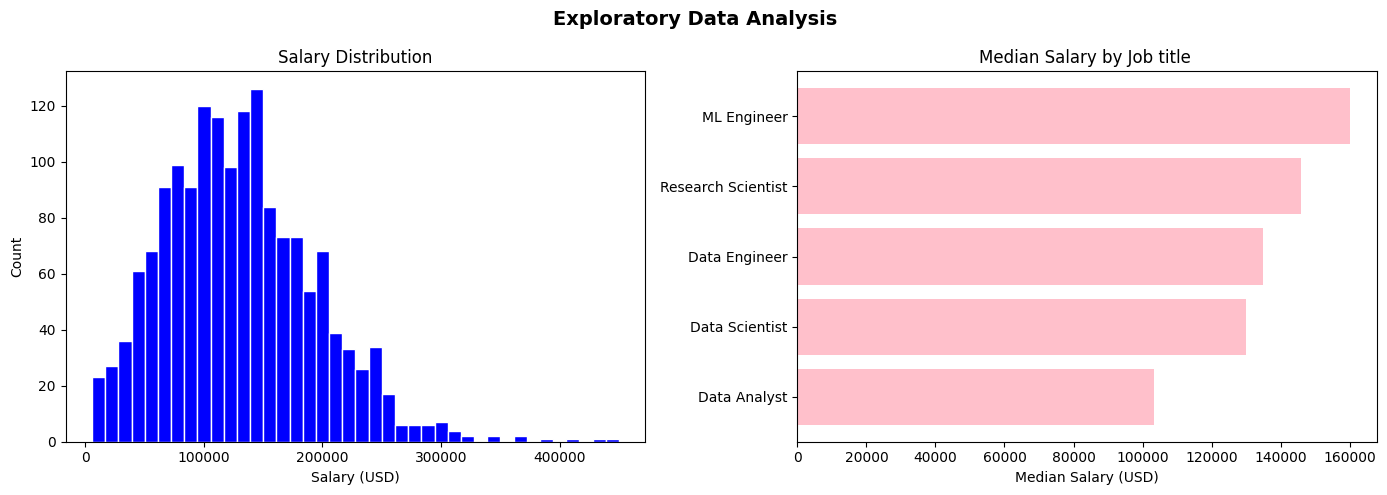

In [43]:
#a look intp salry distribution ans average salary per job title 

fig,axes = plt.subplots(1, 2, figsize=(14, 5))

#salary distribution
axes[0].hist(data[TARGET], bins=40,color = 'blue', edgecolor='white')
axes[0].set_title('Salary Distribution')
axes[0].set_xlabel('Salary (USD)')
axes[0].set_ylabel('Count')

#Average salary by job title 
avg_salary = data.groupby('job_title')[TARGET].median().sort_values()
axes[1].barh(avg_salary.index, avg_salary.values, color = 'pink')
axes[1].set_title('Median Salary by Job title ')
axes[1].set_xlabel('Median Salary (USD)')

plt.suptitle('Exploratory Data Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()